In [ ]:
# ==========================================
#1 Import
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
customers = pd.read_csv("../data/customers.csv")
products = pd.read_csv("../data/products.csv")
orders = pd.read_csv("../data/orders.csv")

print("Customers :", customers.shape)
print("products :", products.shape)
print("orders :", orders.shape)

Customers : (2000, 5)
products : (200, 6)
orders : (50000, 8)


In [ ]:
# ==========================================
#2  Inspect the first 5 rows of each dataset
# ==========================================

print("CUSTOMERS")
display(customers.head())

print("PRODUCTS")
display(products.head())

print("ORDERS")
display(orders.head())

In [ ]:
# ==========================================
#3 Check column names and data types
# ==========================================

print("Customer Info:")
customers.info()

print("Products Info:")
products.info()

print("Orders Info:")
orders.info()

In [ ]:
# ==========================================
#4 Convert order_date to datetime
# ==========================================

orders["order_date"] = pd.to_datetime(orders["order_date"])
orders["month"] = orders["order_date"].dt.month

print("orderdate converted successfully!!")

print("Minimum Date:", orders["order_date"].min())
print("Maximum Date:",orders["order_date"].max())

print("Minimum month:", orders["month"].min())
print("Maximum month:",orders["month"].max())



orderdate converted successfully!!
Minimum Date: 2025-01-01 00:00:00
Maximum Date: 2025-12-31 00:00:00
Minimum month: 1
Maximum month: 12


In [ ]:
# ==========================================
#5 Check missing values
# ==========================================

print("Missing values in customers :")
print(customers.isnull().sum())

print("\nMissing values in products :")
print(products.isnull().sum())

print("\nMissing values in orders :")
print(orders.isnull().sum())



In [ ]:
# ==========================================
#6 Check duplicate IDs
# ==========================================

print("Duplicate order ID's :", orders["order_id"].duplicated().sum())
print("Duplicate customer ID's :", customers["customer_id"].duplicated().sum())
print("Duplicate product ID's :",products["product_id"].duplicated().sum())

In [ ]:
# ==========================================
#7 Check quantity and discount validity
# ==========================================

# 30% is the maximum permitted discount

print("orders with discount <= 0 : ", (orders["quantity"]<= 0).sum())
print("orders with discount < 0 :",(orders["discount"]<0).sum())
print("orders with discount > 30% :", (orders["discount"] > 0.30).sum())

In [ ]:
# ==========================================
#8 Check referential integrity
# ==========================================

invalid_customers = ~orders["customer_id"].isin(customers["customer_id"])
invalid_products = ~orders["product_id"].isin(products["product_id"])

print("orders with invalid customer id's :", invalid_customers.sum())
print("orders with invalid products id's :", invalid_products.sum())

In [ ]:
# ==========================================
#9 NOVACART - OVERALL BUSINESS KPIs
# ==========================================

total_orders = orders["order_id"].nunique()
total_units = orders["quantity"].sum()
total_revenue = orders["revenue"].sum()
total_profit = orders["profit"].sum()

profit_margin = (total_profit / total_revenue) * 100
average_order_value = total_revenue / total_orders
average_discount = orders["discount"].mean()
customers_with_orders = orders["customer_id"].nunique()
products_with_orders = orders["product_id"].nunique()

print("===== NOVACART BUSINESS KPIs =====")
print(f"Total Orders          : {total_orders:,}")
print(f"Total Units Sold      : {total_units:,}")
print(f"Total Revenue         : {total_revenue:,.2f}")
print(f"Total Profit          : {total_profit:,.2f}")
print(f"Profit Margin         : {profit_margin:.2f}%")
print(f"Average Order Value   : {average_order_value:,.2f}")
print(f"Average Discount      : {average_discount:.2f}%")
print(f"Customers with Orders : {customers_with_orders:,}")
print(f"Products with Orders  : {products_with_orders:,}")


===== NOVACART BUSINESS KPIs =====
Total Orders          : 50,000
Total Units Sold      : 116,689
Total Revenue         : 528,339,998.12
Total Profit          : 118,666,632.06
Profit Margin         : 22.46%
Average Order Value   : 10,566.80
Average Discount      : 1034.49%
Customers with Orders : 1,974
Products with Orders  : 200


In [ ]:
# ==========================================
#10 CATEGORY PERFORMANCE ANALYSIS
# ==========================================

category_analysis = orders.merge(
    products[["product_id", "category"]],
    on="product_id",
    how="left"
)

category_summary = category_analysis.groupby(
    "category",
    as_index=False
).agg(
    orders=("order_id", "count"),
    units_sold=("quantity", "sum"),
    revenue=("revenue", "sum"),
    profit=("profit", "sum")
)

# Calculate profit margin
category_summary["profit_margin"] = (
    category_summary["profit"]
    / category_summary["revenue"]
    * 100
)

# Sort by revenue
category_summary = category_summary.sort_values(
    "revenue",
    ascending=False
)

category_summary

,category,orders,units_sold,revenue,profit,profit_margin
5,Home & Kitchen,8869,20622,1.973475e+08,45553446.32,23.082861
2,Electronics,6161,14410,1.387647e+08,29381256.02,21.173433
6,Sports,8512,19963,1.385239e+08,32215272.13,23.256108
3,Fashion,4505,10543,2.074954e+07,4646171.69,22.391687
0,Beauty,6422,15095,1.477016e+07,3066443.65,20.761078
1,Books,9023,21059,1.363031e+07,2760112.24,20.249809
4,Grocery,6508,14997,4.553861e+06,1043930.01,22.924064


In [ ]:
#11 PRODUCT PERFORMANCE ANALYSIS

product_analysis = orders.merge(
    products[
        ["product_id", "product_name", "category", "sub_category"]
    ],
    on="product_id",
    how="left"
)

product_summary = (
    product_analysis
    .groupby(
        [
            "product_id",
            "product_name",
            "category",
            "sub_category"
        ]
    )
    .agg(
        orders=("order_id", "nunique"),
        units_sold=("quantity", "sum"),
        revenue=("revenue", "sum"),
        profit=("profit", "sum")
    )
    .reset_index()
)

# Calculate profit margin
product_summary["profit_margin"] = (
    product_summary["profit"]
    / product_summary["revenue"]
) * 100

# Sort products by revenue
top_products = product_summary.sort_values(
    "revenue",
    ascending=False
)

# Display top 10 products
top_products.head(10)

,product_id,product_name,category,sub_category,orders,units_sold,revenue,profit,profit_margin
53,PROD054,Premium Air Purifier,Home & Kitchen,Appliances,2239,5202,1.026060e+08,25649411.73,24.997970
131,PROD132,Premium Exercise Bike,Sports,Fitness,1496,3468,8.694049e+07,21902623.20,25.192661
8,PROD009,Classic Laptop,Electronics,Computers,512,1238,3.729758e+07,7945961.29,21.304228
37,PROD038,Classic Air Purifier,Home & Kitchen,Appliances,384,917,2.467917e+07,5102455.10,20.675151
9,PROD010,Classic Tablet,Electronics,Computers,312,710,1.360501e+07,2020927.36,14.854287
52,PROD053,Premium Vacuum Cleaner,Home & Kitchen,Appliances,483,1096,1.284826e+07,2028297.53,15.786552
20,PROD021,Premium Smartphone,Electronics,Mobile,156,366,1.191056e+07,2071275.72,17.390252
136,PROD137,Premium Mountain Bicycle,Sports,Cycling,200,446,1.012504e+07,2188386.21,21.613613
19,PROD020,Premium Soundbar,Electronics,Audio,262,605,9.629059e+06,1886759.41,19.594431
120,PROD121,Classic Mountain Bicycle,Sports,Cycling,300,669,9.609851e+06,1162019.85,12.091966


In [ ]:

#12 LOW-MARGIN PRODUCT ANALYSIS

low_margin_products = product_summary.sort_values(
    "profit_margin",
    ascending=True
)

low_margin_products[
    [
        "product_name",
        "category",
        "sub_category",
        "orders",
        "units_sold",
        "revenue",
        "profit",
        "profit_margin"
    ]
].head(10)

,product_name,category,sub_category,orders,units_sold,revenue,profit,profit_margin
101,Premium Moisturizer,Beauty,Skincare,28,65,64448.16,6423.31,9.966631
133,Premium Football,Sports,Outdoor,234,485,935967.89,98581.44,10.532566
99,Classic Electric Toothbrush,Beauty,Personal Care,664,1508,2075512.98,226177.18,10.897411
54,Premium Room Heater,Home & Kitchen,Appliances,227,518,1954286.19,213003.29,10.899289
138,Premium Cycling Gloves,Sports,Cycling,229,522,461358.51,50440.11,10.932953
162,Premium Business Book,Books,Non-Fiction,541,1294,1397300.94,153986.92,11.020312
81,Premium Casual Sneakers,Fashion,Footwear,203,468,725072.04,81618.84,11.256653
193,Premium Coffee,Grocery,Beverages,190,450,270313.27,32222.77,11.920528
181,Classic Dishwash Liquid,Grocery,Household,186,418,60899.90,7329.02,12.034535
120,Classic Mountain Bicycle,Sports,Cycling,300,669,9609850.80,1162019.85,12.091966


In [ ]:
#13 CUSTOMER PERFORMANCE ANALYSIS

customer_analysis = orders.merge(
    customers[
        [
            "customer_id",
            "customer_name",
            "city",
            "state",
            "customer_segment"
        ]
    ],
    on="customer_id",
    how="left"
)

customer_summary = (
    customer_analysis
    .groupby(
        [
            "customer_id",
            "customer_name",
            "city",
            "state",
            "customer_segment"
        ],
        as_index=False
    )
    .agg(
        orders=("order_id", "nunique"),
        units_sold=("quantity", "sum"),
        revenue=("revenue", "sum"),
        profit=("profit", "sum")
    )
)

# Calculate profit margin
customer_summary["profit_margin"] = (
    customer_summary["profit"]
    / customer_summary["revenue"]
) * 100

# Sort customers by revenue
top_customers = customer_summary.sort_values(
    "revenue",
    ascending=False
)

# Display top 10 customers
top_customers[
    [
        "customer_name",
        "city",
        "state",
        "customer_segment",
        "orders",
        "units_sold",
        "revenue",
        "profit",
        "profit_margin"
    ]
].head(10)

,customer_name,city,state,customer_segment,orders,units_sold,revenue,profit,profit_margin
835,Arjun Singh,Noida,Uttar Pradesh,Consumer,393,913,3946182.37,976595.91,24.747866
1321,Vikram Singh,Chennai,Tamil Nadu,Consumer,253,671,3910168.26,912968.51,23.348573
139,Sneha Chopra,Jaipur,Rajasthan,Corporate,319,731,3396577.01,713447.50,21.004897
247,Riya Saxena,Hyderabad,Telangana,Corporate,276,643,3137069.96,662230.44,21.109840
1594,Pooja Sharma,Nashik,Maharashtra,Consumer,288,665,3110297.87,736320.12,23.673621
1065,Ayaan Verma,Kolkata,West Bengal,Small Business,282,643,2918639.92,642905.16,22.027560
1746,Yash Patel,Nagpur,Maharashtra,Consumer,258,624,2450289.55,477941.94,19.505529
1153,Aarav Nair,Delhi,Delhi,Consumer,188,465,2369675.36,576689.81,24.336237
477,Kabir Reddy,Indore,Madhya Pradesh,Corporate,214,478,1933198.85,363021.76,18.778294
1181,Reyansh Singh,Indore,Madhya Pradesh,Small Business,133,326,1866010.47,411489.35,22.051824


In [ ]:
# ==========================================
#14 CUSTOMER SEGMENT ANALYSIS
# ==========================================

segment_analysis = (
    customer_summary
    .groupby("customer_segment", as_index=False)
    .agg(
        customers=("customer_id", "nunique"),
        orders=("orders", "sum"),
        units_sold=("units_sold", "sum"),
        revenue=("revenue", "sum"),
        profit=("profit", "sum")
    )
)

# Calculate profit margin
segment_analysis["profit_margin"] = (
    segment_analysis["profit"]
    / segment_analysis["revenue"]
) * 100

# Sort by revenue
segment_analysis = segment_analysis.sort_values(
    "revenue",
    ascending=False
)

segment_analysis

,customer_segment,customers,orders,units_sold,revenue,profit,profit_margin
0,Consumer,1389,34690,80995,3.689272e+08,82610658.35,22.392129
1,Corporate,390,10209,23718,1.050413e+08,23816152.96,22.673123
2,Small Business,195,5101,11976,5.437145e+07,12239820.75,22.511486


In [ ]:
# ==========================================    
#15 STATE-LEVEL PERFORMANCE ANALYSIS
# ==========================================

state_analysis = orders.merge(
    customers[
        [
            "customer_id",
            "state"
        ]
    ],
    on="customer_id",
    how="left"
)

state_analysis = state_analysis.groupby(
    "state",
    as_index=False
).agg(
    customers=("customer_id", "nunique"),
    orders=("order_id", "count"),
    units_sold=("quantity", "sum"),
    revenue=("revenue", "sum"),
    profit=("profit", "sum")
)

state_analysis["profit_margin"] = (
    state_analysis["profit"]
    / state_analysis["revenue"]
    * 100
)

state_analysis = state_analysis.sort_values(
    "revenue",
    ascending=False
)

state_analysis

,state,customers,orders,unit_sold,revenue,profit,profit_margin
7,Maharashtra,426,10492,24719,1.127933e+08,25220308.63,22.359756
11,Uttar Pradesh,205,5160,12042,5.434171e+07,12231864.78,22.509162
9,Tamil Nadu,169,4521,10618,4.909573e+07,11329336.72,23.076015
4,Karnataka,172,4131,9550,4.414940e+07,9918068.51,22.464788
2,Gujarat,166,4040,9461,4.190888e+07,9428170.47,22.496832
6,Madhya Pradesh,113,3310,7638,3.613514e+07,7983130.37,22.092428
12,West Bengal,111,2882,6757,3.085452e+07,6881590.06,22.303349
10,Telangana,103,3057,6963,3.071724e+07,6920466.15,22.529583
1,Delhi,110,2840,6586,2.837086e+07,6375841.15,22.473204
5,Kerala,98,2594,5939,2.675281e+07,6044800.73,22.595015


In [ ]:
# ==========================================
#16  TOP 10 CUSTOMER REVENUE CONCENTRATION
# ==========================================

# Calculate total business revenue
total_revenue = customer_summary["revenue"].sum()

# Get Top 10 customers by revenue
top_10_customers = (
    customer_summary
    .sort_values("revenue", ascending=False)
    .head(10)
)

# Calculate Top 10 customer revenue
top_10_customer_revenue = top_10_customers["revenue"].sum()

# Calculate Top 10 revenue contribution
top_10_customer_percentage = (
    top_10_customer_revenue / total_revenue
) * 100

# Display summary
print("===== TOP 10 CUSTOMER REVENUE CONCENTRATION =====")
print("Total Revenue           :", round(total_revenue, 2))
print("Top 10 Customer Revenue :", round(top_10_customer_revenue, 2))
print(
    "Top 10 Revenue Share    :",
    round(top_10_customer_percentage, 2),
    "%"
)

# Display Top 10 customers
top_10_customers[
    [
        "customer_name",
        "city",
        "state",
        "customer_segment",
        "orders",
        "units_sold",
        "revenue",
        "profit",
        "profit_margin"
    ]
]

In [ ]:
# ==========================================
#17 TOP 10 PRODUCT REVENUE CONCENTRATION
# ==========================================

# Calculate total business revenue
total_revenue = product_summary["revenue"].sum()

# Get Top 10 products by revenue
top_10_products = (
    product_summary
    .sort_values("revenue", ascending=False)
    .head(10)
)

# Calculate Top 10 product revenue
top_10_product_revenue = top_10_products["revenue"].sum()

# Calculate Top 10 revenue contribution
top_10_product_percentage = (
    top_10_product_revenue / total_revenue
) * 100

# Display summary
print("===== TOP 10 PRODUCT REVENUE CONCENTRATION =====")
print("Total Revenue           :", round(total_revenue, 2))
print("Top 10 Product Revenue  :", round(top_10_product_revenue, 2))
print(
    "Top 10 Product Revenue %:",
    round(top_10_product_percentage, 2),
    "%"
)

# Display Top 10 products
top_10_products[
    [
        "product_name",
        "category",
        "sub_category",
        "revenue",
        "profit",
        "profit_margin"
    ]
]

In [ ]:
# ==========================================
#18 DISCOUNT IMPACT ON PROFITABILITY
# ==========================================

discount_analysis = orders.groupby(
    "discount",
    as_index=False
).agg(
    orders=("order_id", "count"),
    units_sold=("quantity", "sum"),
    revenue=("revenue", "sum"),
    profit=("profit", "sum")
)

# Calculate profit margin
discount_analysis["profit_margin"] = (
    discount_analysis["profit"]
    / discount_analysis["revenue"]
    * 100
)

# Sort by discount
discount_analysis = discount_analysis.sort_values(
    "discount"
)

discount_analysis

In [ ]:
# ==========================================
#19 DISCOUNT vs PROFIT MARGIN
# ==========================================

plt.figure (figsize=(8,5))


plt.plot(
    discount_analysis["discount"],
    discount_analysis["profit_margin"],
    marker = "o"
)

plt.xlabel("Discount (%)")
plt.ylabel("Profit Margin (%)")
plt.title("Impact of Discount on Profit Margin")

plt.grid(True)
plt.show()

In [ ]:
# ==========================================
# 20 QUANTITY & ORDER VALUE ANALYSIS
# ==========================================

quantity_analysis = (
    orders
    .groupby("quantity", as_index=False)
    .agg(
        orders=("order_id", "nunique"),
        total_revenue=("revenue", "sum"),
        total_profit=("profit", "sum")
    )
)

# Average revenue per order
quantity_analysis["average_order_revenue"] = (
    quantity_analysis["total_revenue"]
    / quantity_analysis["orders"]
)

# Profit margin
quantity_analysis["profit_margin"] = (
    quantity_analysis["total_profit"]
    / quantity_analysis["total_revenue"]
) * 100

# Sort by quantity
quantity_analysis = quantity_analysis.sort_values(
    "quantity"
)

quantity_analysis

In [ ]:
# ==========================================
#21 QUANTITY vs AVERAGE ORDER REVENUE
# ==========================================

plt.figure(figsize=(8, 5))

plt.plot(
    quantity_analysis["quantity"],
    quantity_analysis["average_order_revenue"],
    marker="o"
)

plt.xlabel("Quantity per Order")
plt.ylabel("Average Order Revenue")
plt.title("Quantity vs Average Order Revenue")

plt.grid(True)

plt.show()

In [ ]:
# ==========================================
# 22 MONTHLY REVENUE ANALYSIS
# ==========================================

monthly_analysis = orders.groupby(
    "month",
    as_index=False
).agg(
    orders=("order_id", "count"),
    revenue=("revenue", "sum"),
    profit=("profit", "sum")
)

monthly_analysis["profit_margin"] = (
    monthly_analysis["profit"]
    / monthly_analysis["revenue"]
    * 100
)

monthly_analysis["month_name"] = monthly_analysis["month"].map({
    1: "January",
    2: "February",
    3: "March",
    4: "April",
    5: "May",
    6: "June",
    7: "July",
    8: "August",
    9: "September",
    10: "October",
    11: "November",
    12: "December"
})

monthly_analysis

In [ ]:
# ==========================================
#23 MONTHLY REVENUE TREND
# ==========================================

plt.figure(figsize=(10, 5))

plt.plot(
    monthly_analysis["month_name"],
    monthly_analysis["revenue"],
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Revenue")
plt.title("Monthly Revenue Trend")

plt.xticks(rotation=45)
plt.grid(True)

plt.show()

In [ ]:
# ==========================================
#24 MONTHLY PROFIT TREND
# ==========================================

plt.figure(figsize=(10, 5))

plt.plot(
    monthly_analysis["month_name"],
    monthly_analysis["profit"],
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Profit")
plt.title("Monthly Profit Trend")

plt.xticks(rotation=45)
plt.grid(True)

plt.show()

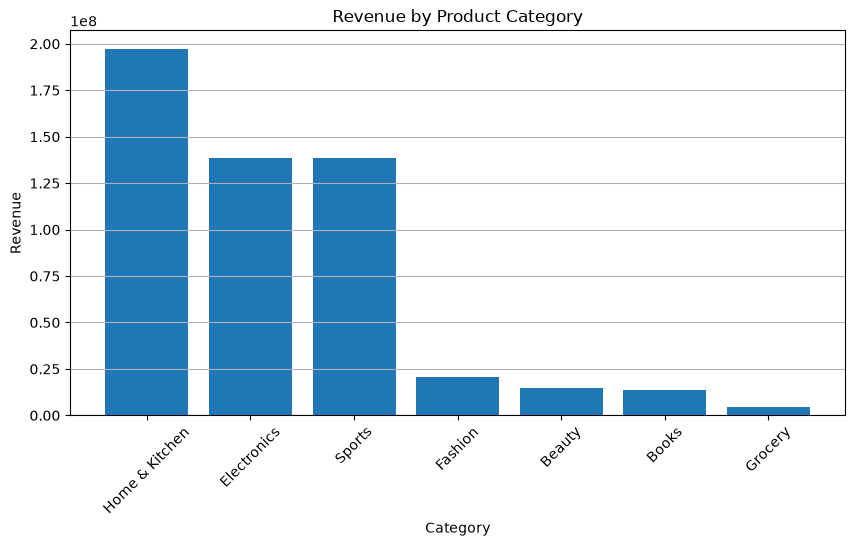

In [ ]:
# ==========================================
#25 CATEGORY REVENUE ANALYSIS
# ==========================================

plt.figure(figsize=(10, 5))

plt.bar(
    category_summary["category"],
    category_summary["revenue"]
)

plt.xlabel("Category")
plt.ylabel("Revenue")
plt.title("Revenue by Product Category")

plt.xticks(rotation=45)
plt.grid(axis="y")

plt.show()

# Business Insights & Recommendations

## Key Business Insights

### 1. Overall Business Performance
- NovaCart processed **50,000 orders** and sold **116,689 units**.
- Total revenue was approximately **₹528.34M**.
- Total profit was approximately **₹118.67M**.
- Overall profit margin was **22.46%**.

### 2. Monthly Performance
- **December** recorded the highest monthly revenue and profit.
- **February** recorded the lowest monthly revenue and profit.
- Revenue and profit generally strengthened toward the end of the year.

### 3. Category & Product Performance
- **Home & Kitchen** was the highest-revenue and highest-profit category.
- **Sports** also demonstrated strong profitability.
- Several products generated substantial revenue but operated at comparatively low profit margins.
- Low-margin products should be reviewed for pricing, costs, and discount strategy.

### 4. Customer Performance
- **Consumer** customers represent the largest customer segment and the primary revenue contributor.
- **Corporate** customers achieved the highest profit margin among the three segments.
- Revenue is relatively diversified, with the **top 10 customers contributing approximately 5.50%** of total revenue.

### 5. Discount Impact
- Higher discount levels are associated with substantially lower profit margins.
- Profit margin declined from **30.47% at 0% discount** to **1.04% at 30% discount**.
- Discounting should therefore be targeted rather than applied broadly.

### 6. Order Quantity
- Larger quantities generally produce higher average order revenue.
- Profit margins remain relatively stable across most order quantities.
- Bundling and cross-selling could help increase average order value.

## Business Recommendations

1. **Prioritize high-performing categories and products** while maintaining inventory availability.
2. **Review low-margin products** and evaluate pricing, supplier costs, and discount levels.
3. **Control excessive discounting** and use targeted promotions where profitability remains acceptable.
4. **Increase basket size** through bundles, cross-selling, and complementary products.
5. **Investigate December's strong performance** to identify repeatable seasonal opportunities.
6. **Analyze the weaker February period** and consider targeted campaigns or promotions.
7. **Strengthen Corporate and Small Business relationships** while continuing to retain the large Consumer customer base.

## Overall Recommendation

NovaCart should prioritize **profitable growth rather than sales growth alone** by improving product margins, controlling discounting, strengthening high-performing categories, and expanding profitable customer opportunities.